Train_full class counts: {'cell': 149, 'steroid': 39}
Test class counts: {'cell': 38, 'steroid': 10}
Before oversample: Counter({np.int64(0): 130, np.int64(1): 34})
After  oversample: Counter({np.int64(1): 156, np.int64(0): 130})
Train class counts: {'cell': 130, 'steroid': 34}
Val class counts: {'cell': 19, 'steroid': 5}


c:\Users\localAdmin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(



=== UT Test (Calibrated, Argmax) ===
Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

        cell     0.9737    0.9737    0.9737        38
     steroid     0.9000    0.9000    0.9000        10

    accuracy                         0.9583        48
   macro avg     0.9368    0.9368    0.9368        48
weighted avg     0.9583    0.9583    0.9583        48


=== UT Test (Calibrated, Thresholded) ===
Accuracy: 0.9791666666666666
              precision    recall  f1-score   support

        cell     1.0000    0.9737    0.9867        38
     steroid     0.9091    1.0000    0.9524        10

    accuracy                         0.9792        48
   macro avg     0.9545    0.9868    0.9695        48
weighted avg     0.9811    0.9792    0.9795        48

Calibrated thresholds: {'cell': np.float64(0.55), 'steroid': np.float64(0.3)}

=== TEST (argmax) ===
Accuracy: 0.9792
              precision    recall  f1-score   support

        cell     1.0000    0.9737 

<Figure size 640x480 with 0 Axes>

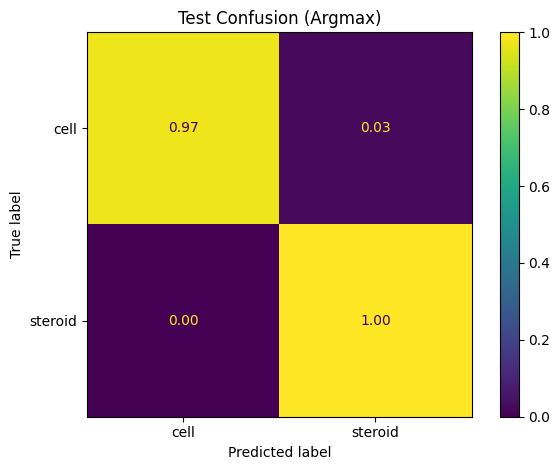

<Figure size 640x480 with 0 Axes>

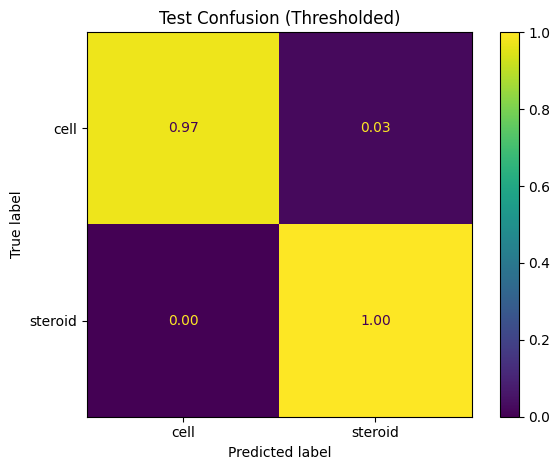

In [1]:

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost.callback import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, f1_score, accuracy_score
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier
from collections import Counter
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Optional (commented) oversampling
# from imblearn.over_sampling import RandomOverSampler

# ==============
# 1) Load & filter dataset
# ==============
excel_path = "UTA_new.xlsx"  # <-- update if needed


data = pd.read_excel(excel_path)
data = data.dropna(subset=['Kd (nM)', 'Aptamer Sequence', 'Target']).copy()



def extract_target_group(target: str) -> str:
    t = str(target).lower()
    #if 'peptide' in t:
     #   return 'peptide'
    if 'cell' in t:
        return 'cell'
    #if 'protein' in t:
     #   return 'protein'
    if 'steroid' in t:
        return 'steroid'
    return 'other'

data['target_group'] = data['Target'].apply(extract_target_group)
# keep only the four groups
data = data[data['target_group'].isin(['cell', 'steroid'])].reset_index(drop=True)

# ==============
# 2) Features (6-mer TF-IDF + simple numerics)
# ==============
# === PATCH 1: Feature construction (char n-grams + simple numerics) ===
from sklearn.feature_extraction.text import TfidfVectorizer

# Use raw sequences instead of pre-tokenized 6-mers
seq_series = data['Aptamer Sequence'].astype(str).str.upper().str.replace(r'\s+', '', regex=True)

# Character TF-IDF captures motifs (3..6) robustly
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 6), min_df=2, max_features=30000)
X_seq = vectorizer.fit_transform(seq_series)

# Keep your simple numeric features
data['seq_length'] = data['Aptamer Sequence'].apply(lambda s: len(str(s)))
data['gc_content'] = data['Aptamer Sequence'].apply(
    lambda s: (str(s).upper().count('G') + str(s).upper().count('C')) / max(len(str(s)), 1)
)
X_num = data[['seq_length', 'gc_content']].values

from scipy.sparse import hstack, csr_matrix
X = csr_matrix(hstack([X_seq, X_num]))

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(data['target_group'])


# ==============
# 3) Split Train/Test once
# ==============
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train_full class counts:", {le.inverse_transform([k])[0]: v for k, v in Counter(y_train_full).items()})
print("Test class counts:", {le.inverse_transform([k])[0]: v for k, v in Counter(y_test).items()})

# We'll treat X_train_full/y_train_full as "Train+Val" pool
X_trainval, y_trainval = X_train_full, y_train_full

# ==============
# 4) Make ONE fixed Train/Val split (used by all bagged models)
# ==============
VAL_FRACTION_OF_TEMP = 0.125  # ~10% of total data as validation

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_FRACTION_OF_TEMP,
    stratify=y_trainval,
    random_state=2025  # fixed seed
)

# map label <-> class name
idx_to_name = dict(enumerate(le.classes_))
name_to_idx = {v: k for k, v in idx_to_name.items()}
steroid_idx = name_to_idx.get('steroid', None)

cnt_before = Counter(y_train)
majority_n = max(cnt_before.values())

if steroid_idx is not None:
    sampling_strategy = {steroid_idx: int(1.2 * majority_n)}  # try 1.3–1.6 later if needed
    ros = RandomOverSampler(random_state=42, sampling_strategy=sampling_strategy)
    X_train_rs, y_train_rs = ros.fit_resample(X_train, y_train)
else:
    X_train_rs, y_train_rs = X_train, y_train

print("Before oversample:", cnt_before)
print("After  oversample:", Counter(y_train_rs))

# Recompute class weights after oversampling (keeps a small balance pressure)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_rs)

# Optional: oversample ONLY the training set (commented out; enable if needed)
# ros = RandomOverSampler(random_state=42)
# X_train, y_train, sample_weights = ros.fit_resample(X_train, y_train, sample_weight=sample_weights)

print("Train class counts:", {le.inverse_transform([k])[0]: v for k, v in Counter(y_train).items()})
print("Val class counts:",   {le.inverse_transform([k])[0]: v for k, v in Counter(y_val).items()})

# ==============
# 5) Bagging ensemble with early stopping (fixed val set)
# ==============
n_models = 9
ensemble_val_predictions  = []
ensemble_test_predictions = []

for run in range(n_models):
    model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=4,
    subsample=0.8,
    gamma = 0.2,
    colsample_bytree=0.8,
    colsample_bynode=0.8,
    reg_lambda=1.0,
    random_state=run,
    n_jobs=-1,
    eval_metric='mlogloss'   # <-- put it here
)

    model.fit(
    X_train_rs, y_train_rs,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)


    # Collect probabilities for ensembling
    preds_proba_val  = model.predict_proba(X_val)
    preds_proba_test = model.predict_proba(X_test)

    ensemble_val_predictions.append(preds_proba_val)
    ensemble_test_predictions.append(preds_proba_test)

# Average probs across bagged models
val_proba  = np.mean(np.array(ensemble_val_predictions),  axis=0)
test_proba = np.mean(np.array(ensemble_test_predictions), axis=0)

calib_model = LogisticRegression(multi_class='multinomial', max_iter=500)
calib_model.fit(val_proba, y_val)

# --- Calibrate VAL & TEST probabilities ---
val_proba_cal  = calib_model.predict_proba(val_proba)
test_proba_cal = calib_model.predict_proba(test_proba)

# ==============
# 6) Baseline (argmax) and threshold-tuned decoding
# ==============
def tune_thresholds_multiclass(proba, y_true, n_classes, grid=None, passes=3):
    """
    Learn per-class thresholds τ_c on a validation set to maximize macro-F1.
    Decoding rule picks argmax_i p_i / τ_i.
    """
    if grid is None:
        grid = np.linspace(0.2, 1.2, 21)  # search space for τ
    th = np.ones(n_classes)
    for _ in range(passes):
        for c in range(n_classes):
            best_tau, best_f1 = th[c], -1.0
            for tau in grid:
                th_try = th.copy()
                th_try[c] = tau
                y_hat = (proba / th_try).argmax(axis=1)
                f1 = f1_score(y_true, y_hat, average='macro')
                if f1 > best_f1:
                    best_f1, best_tau = f1, tau
            th[c] = best_tau
    return th

num_classes = len(le.classes_)
thresh_cal = tune_thresholds_multiclass(val_proba_cal, y_val, num_classes)

pred_argmax_cal = test_proba_cal.argmax(axis=1)
pred_thr_cal    = (test_proba_cal / thresh_cal).argmax(axis=1)

print("\n=== UT Test (Calibrated, Argmax) ===")
print("Accuracy:", accuracy_score(y_test, pred_argmax_cal))
print(classification_report(y_test, pred_argmax_cal, target_names=le.classes_, digits=4, zero_division=0))

print("\n=== UT Test (Calibrated, Thresholded) ===")
print("Accuracy:", accuracy_score(y_test, pred_thr_cal))
print(classification_report(y_test, pred_thr_cal, target_names=le.classes_, digits=4, zero_division=0))
print("Calibrated thresholds:", dict(zip(le.classes_, np.round(thresh_cal, 3))))

# Argmax (no thresholding)
test_pred_argmax = test_proba.argmax(axis=1)
print("\n=== TEST (argmax) ===")
print(f"Accuracy: {accuracy_score(y_test, test_pred_argmax):.4f}")
print(classification_report(y_test, test_pred_argmax, target_names=le.classes_, digits=4, zero_division=0))

# Threshold-tuned decoding
num_classes = len(le.classes_)
thresh = tune_thresholds_multiclass(val_proba, y_val, num_classes)
test_pred_thr = (test_proba / thresh).argmax(axis=1)

test_proba_cal = calib_model.predict_proba(test_proba)

print("\n=== TEST (thresholded) ===")
print(f"Accuracy: {accuracy_score(y_test, test_pred_thr):.4f}")
print(classification_report(y_test, test_pred_thr, target_names=le.classes_, digits=4, zero_division=0))
print("Chosen thresholds:", dict(zip(le.classes_, np.round(thresh, 3))))

val_argmax = val_proba.argmax(axis=1)
val_thr    = (val_proba / thresh).argmax(axis=1)
print("VAL macro-F1 (argmax):    ", f1_score(y_val, val_argmax, average='macro'))
print("VAL macro-F1 (threshold): ", f1_score(y_val, val_thr,    average='macro'))

# ==============
# 7) New aptamer predictions (reuse same split/weights; same thresholds)
# ==============
# Update this path as needed:
new_csv_path = r"C:\Users\avapg\Downloads\andres_steroids - Sheet1.csv"
try:
    new_data = pd.read_csv(new_csv_path)
except Exception as e:
    print(f"\n[WARN] Could not read new aptamer CSV at: {new_csv_path}\n{e}\n")
    new_data = None

if new_data is not None and 'SEQ' in new_data.columns:
    # Generate same features
    new_data['kmer_sequence'] = new_data['SEQ'].apply(lambda s: get_kmers(s, k=6))
    new_data['seq_length'] = new_data['SEQ'].apply(lambda s: len(str(s)))
    new_data['gc_content'] = new_data['SEQ'].apply(
        lambda s: (str(s).upper().count('G') + str(s).upper().count('C')) / max(len(str(s)), 1)
    )

    # Transform with the same vectorizer
    X_kmer_new = vectorizer.transform(new_data['kmer_sequence'])
    X_num_new = new_data[['seq_length', 'gc_content']].values
    X_new = csr_matrix(hstack([X_kmer_new, X_num_new]))

    # Re-train bagged models (same split/weights) and predict NEW
    ensemble_new_preds = []
    for run in range(n_models):
        model = XGBClassifier(
        objective='multi:softprob',
        num_class=len(le.classes_),
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=4,
        subsample=0.8,
        gamma = 0.2,
        colsample_bytree=0.8,
        colsample_bynode=0.8,
        reg_lambda=1.0,
        random_state=run,
        n_jobs=-1,
        eval_metric='mlogloss'   # put eval_metric here, not in fit()
)
        
        model.fit(
            X_train_rs, y_train_rs,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=75,
            verbose=False
        )
        preds_proba_new = model.predict_proba(X_new)
        ensemble_new_preds.append(preds_proba_new)

    final_proba_new = np.mean(np.array(ensemble_new_preds), axis=0)

    # Decode with learned thresholds
    final_pred_new = (final_proba_new / thresh).argmax(axis=1)
    new_data['Predicted_Group'] = le.inverse_transform(final_pred_new)

    # Save predictions
    out_path = "new_test_aptamers_with_predictions.csv"
    new_data.to_csv(out_path, index=False)
    print("\nSaved:", out_path)
    try:
        print(new_data[['SEQ', 'Predicted_Group']])
    except Exception:
        print(new_data.head())
else:
    print("\n[INFO] Skipping new aptamer predictions (no CSV loaded or 'SEQ' column missing).")

def show_confusions(y_true, y_pred, title):
    plt.figure()
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize='true', values_format='.2f',
        display_labels=le.classes_
    )
    plt.title(title)
    plt.tight_layout()

    

show_confusions(y_test, test_pred_argmax, "Test Confusion (Argmax)")
# If you still compute thresholded preds:
show_confusions(y_test, test_pred_thr, "Test Confusion (Thresholded)")
plt.show()



In [2]:
import os
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csc_matrix
from sklearn.calibration import CalibratedClassifierCV

new_excel_path = "Amanda_seq.xlsx"
data2_amanda = pd.read_excel(new_excel_path)
output_csv     = "Amanda_seq_scored8.csv"

def add_simple_seq_features_from_series(seqs: pd.Series):
    """Create simple, portable numeric features (length, GC%) that work for new data."""
    s = seqs.astype(str).str.upper()
    lens = s.str.len().astype(float).to_numpy().reshape(-1, 1)
    gc   = (s.str.count('G') + s.str.count('C')).to_numpy().reshape(-1, 1)
    gc_ratio = np.divide(gc, np.maximum(lens, 1.0))  # avoid div-by-zero
    return csc_matrix(np.hstack([lens, gc_ratio]))

def _get_sequence_series_from_excel(df: pd.DataFrame) -> pd.Series:
    """Try to fin d a column containing aptamer sequences, case-insensitively."""
    cols = [c for c in df.columns]
    # prefer columns that look like "Aptamer Sequence" or "Sequence"
    candidates = [c for c in cols if ("sequence" in c.lower()) or ("aptamer" in c.lower())]
    if not candidates:
        # fallback: first text-like column
        for c in cols:
            if df[c].dtype == object:
                candidates = [c]
                break
    if not candidates:
        raise ValueError("Could not find a sequence column in the Excel sheet.")
    return df[candidates[0]].astype(str)

# ---- load and predict ----
if not os.path.exists(new_excel_path):
    raise FileNotFoundError(f"File not found: {new_excel_path}")

new_df_raw = pd.read_excel(new_excel_path)
seq_series = _get_sequence_series_from_excel(new_df_raw).copy()

# transform with the SAME vectorizer you trained earlier
new_df_raw = new_df_raw.dropna(subset=["SEQSt"]).copy()
new_df_raw = new_df_raw[new_df_raw["SEQSt"].astype(str).str.strip() != ""].copy()
seq_series = new_df_raw["SEQSt"].astype(str)

X_seq_new = vectorizer.transform(seq_series)

# add simple features that do not require labels/Kd
X_simple_new = add_simple_seq_features_from_series(seq_series)

# if your training used ONLY TF-IDF, comment the next line and use X_seq_new directly
X_new = hstack([X_seq_new, X_simple_new])

# get probabilities from your trained model(s)
# - If you have an ensemble list called `models`, we average them.
# - Else, we assume a single fitted `model`.
if "models" in globals() and isinstance(models, (list, tuple)) and len(models) > 0:
    probs_list = [m.predict_proba(X_new) for m in models]
    proba_new = np.mean(np.stack(probs_list, axis=0), axis=0)
elif "model" in globals():
    proba_new = model.predict_proba(X_new)
else:
    raise RuntimeError("No trained model(s) found. Expected `models` (list) or `model` (single).")

# decode predictions
# assumes you have a fitted LabelEncoder `le`
pred_argmax = le.inverse_transform(np.argmax(proba_new, axis=1))

# optional thresholded predictions if you have `thresh` learned on your validation set
if "thresh" in globals():
    pred_thr = le.inverse_transform(np.argmax(proba_new / thresh, axis=1))
else:
    pred_thr = None

# build output table
out = new_df_raw.copy()
out["Predicted (argmax)"] = pred_argmax
if pred_thr is not None:
    out["Predicted (thresholded)"] = pred_thr

# add per-class probabilities (rounded for readability)
for i, cls in enumerate(le.classes_):
    out[f"P({cls})"] = np.round(proba_new[:, i], 4)

# save
out.to_csv(output_csv, index=False)
print(f"Saved predictions → {output_csv}")
# If you're in Jupyter, also show the head:
out.head()

# === Calibrate Amanda probabilities (use the averaged proba_new) ===
# Requires: calib_model (fitted on val_proba vs y_val) and thresh_cal (thresholds tuned on calibrated VAL)

# Use your already-averaged ensemble probabilities
amanda_proba_raw = proba_new

# Map to calibrated probabilities
amanda_proba_cal = calib_model.predict_proba(amanda_proba_raw)

# Decode labels
amanda_pred_argmax_cal = le.inverse_transform(amanda_proba_cal.argmax(axis=1))
amanda_pred_thr_cal    = le.inverse_transform((amanda_proba_cal / thresh_cal).argmax(axis=1))

# Write a CALIBRATED CSV alongside your uncalibrated one
out_cal = out.copy()
out_cal["Predicted (argmax, calibrated)"]       = amanda_pred_argmax_cal
out_cal["Predicted (thresholded, calibrated)"]  = amanda_pred_thr_cal
for i, cls in enumerate(le.classes_):
    out_cal[f"P({cls}) [cal]"] = np.round(amanda_proba_cal[:, i], 4)

out_cal.to_csv("Amanda_seq_scored_CALIBRATED.csv", index=False)
print("Saved calibrated predictions → Amanda_seq_scored_CALIBRATED.csv")

print("amanda_proba_raw shape:", amanda_proba_raw.shape)   # (n_rows, n_classes)
print("amanda_proba_cal shape:", amanda_proba_cal.shape)   # same shape

Saved predictions → Amanda_seq_scored8.csv
Saved calibrated predictions → Amanda_seq_scored_CALIBRATED.csv
amanda_proba_raw shape: (13, 2)
amanda_proba_cal shape: (13, 2)
